In [11]:
import numpy as np
import matplotlib.pyplot as plt
import importlib

import sheet2_work
importlib.reload(sheet2_work)

from sheet2_work import kmeans, em_gmm, plot_gmm_solution, agglo_dendro, kmeans_agglo

In [12]:
X = np.load("problem_set2/data/2_gaussians.npy").T

print(X.shape)
print(X[:5])

(200, 2)
[[ 1.2046149   0.64178414]
 [ 0.13424835  0.53500803]
 [-0.31802168  0.57707245]
 [ 1.3242925   0.47485369]
 [ 2.0190895   0.45978977]]


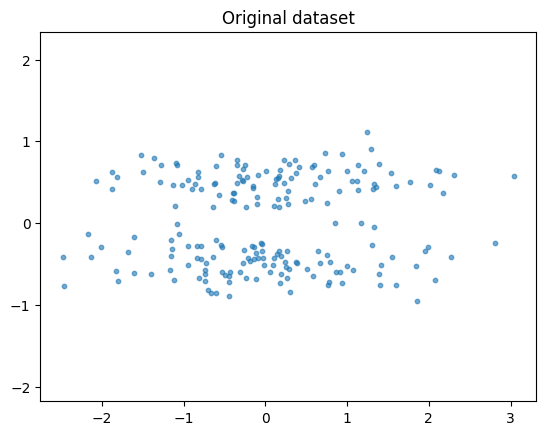

In [13]:
plt.scatter(X[:,0], X[:,1], s=10, alpha=0.6)
plt.axis("equal")
plt.title("Original dataset")
plt.show()

Iteration 1, number of changes: 4, loss: 149.36382412226817
Iteration 2, number of changes: 4, loss: 142.9700194767008
Iteration 3, number of changes: 4, loss: 142.93190198249175
Iteration 4, number of changes: 4, loss: 142.8728669695359
Iteration 5, number of changes: 0, loss: 142.8728669695359


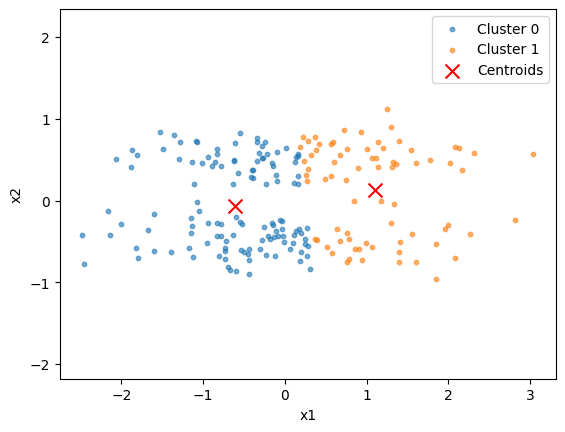

In [14]:
k = 2
mu, r, loss = kmeans(X, k)


plt.figure()

for j in range(k):
    mask = (r == j)
    plt.scatter(
        X[mask, 0],
        X[mask, 1],
        s=10,
        alpha=0.6,
        label=f"Cluster {j}"
    )

plt.scatter(
    mu[:,0],
    mu[:,1],
    c='red',
    marker='x',
    s=100,
    label='Centroids'
)

plt.legend()
# plt.title(f"K-means, k={k}, loss={loss:.2f}")
plt.xlabel("x1")
plt.ylabel("x2")
plt.axis("equal")
plt.show()

In [15]:
best_loss = {k: np.inf for k in range(2, 8)}

for _ in range(100):
    for k in range(2, 8):
        mu, r, loss = kmeans(X, k)
        if loss < best_loss[k]:
            best_loss[k] = loss

print("Best losses for k=2 to 7:")
for k, loss in best_loss.items():
    print(f"k={k}: {loss:.2f}")


Iteration 1, number of changes: 4, loss: 209.9057782684206
Iteration 2, number of changes: 4, loss: 176.66722990972542
Iteration 3, number of changes: 4, loss: 158.5669326902983
Iteration 4, number of changes: 4, loss: 151.19225767718552
Iteration 5, number of changes: 4, loss: 146.98541535575797
Iteration 6, number of changes: 4, loss: 143.90654234172513
Iteration 7, number of changes: 4, loss: 142.45863717472102
Iteration 8, number of changes: 4, loss: 142.27378815744834
Iteration 9, number of changes: 4, loss: 142.2301564736166
Iteration 10, number of changes: 0, loss: 142.2301564736166
Iteration 1, number of changes: 6, loss: 145.25315960246866
Iteration 2, number of changes: 6, loss: 130.43272973579286
Iteration 3, number of changes: 6, loss: 124.30302203139192
Iteration 4, number of changes: 6, loss: 121.01412683206347
Iteration 5, number of changes: 6, loss: 118.7288646337606
Iteration 6, number of changes: 6, loss: 117.16916646207858
Iteration 7, number of changes: 6, loss: 116

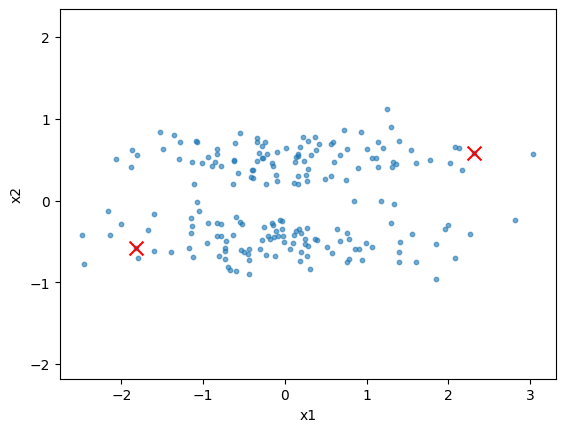

Iteration 1, log-likelihood: -720.445604
Iteration 2, log-likelihood: -458.185532
Iteration 3, log-likelihood: -456.759568
Iteration 4, log-likelihood: -456.179187
Iteration 5, log-likelihood: -455.887188
Iteration 6, log-likelihood: -455.720944
Iteration 7, log-likelihood: -455.618236
Iteration 8, log-likelihood: -455.550970
Iteration 9, log-likelihood: -455.504935
Iteration 10, log-likelihood: -455.472324
Iteration 11, log-likelihood: -455.448563
Iteration 12, log-likelihood: -455.430838
Iteration 13, log-likelihood: -455.417344
Iteration 14, log-likelihood: -455.406884
Iteration 15, log-likelihood: -455.398642
Iteration 16, log-likelihood: -455.392051
Iteration 17, log-likelihood: -455.386703
Iteration 18, log-likelihood: -455.382306
Iteration 19, log-likelihood: -455.378642
Iteration 20, log-likelihood: -455.375551
Iteration 21, log-likelihood: -455.372911
Iteration 22, log-likelihood: -455.370628
Iteration 23, log-likelihood: -455.368631
Iteration 24, log-likelihood: -455.366863
I

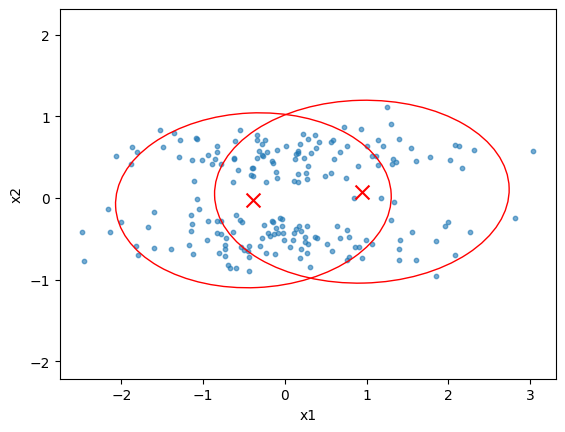

In [31]:
# k = 2
# pi, mu, sigma, loglik = em_gmm(X, k, init_kmeans=True)
# plot_gmm_solution(X, mu, sigma)

k = 2
pi, mu, sigma, loglik = em_gmm(X, k, init_kmeans=False)
plot_gmm_solution(X, mu, sigma)

In [ ]:
for _ in range(100):
    for k in range(2, 8):
        pi, mu, sigma, loglik = em_gmm(X, k, init_kmeans=True)
        if loglik < best_loss[k]:
            best_loss[k] = loglik

print("Best losses for k=2 to 7:")
for k, loss in best_loss.items():
    print(f"k={k}: {loss:.2f}")


In [228]:
best_loss = {k: np.inf for k in range(2, 8)}

for _ in range(100):
    for k in range(2, 8):
        pi, mu, sigma, loglik = em_gmm(X, k, init_kmeans=False)
        if loglik < best_loss[k]:
            best_loss[k] = loglik

print("Best losses for k=2 to 7:")
for k, loss in best_loss.items():
    print(f"k={k}: {loss:.2f}")

Iteration 1, log-likelihood: -530.424316
Iteration 2, log-likelihood: -455.819837
Iteration 3, log-likelihood: -455.651350
Iteration 4, log-likelihood: -455.584110
Iteration 5, log-likelihood: -455.552608
Iteration 6, log-likelihood: -455.533904
Iteration 7, log-likelihood: -455.519797
Iteration 8, log-likelihood: -455.507270
Iteration 9, log-likelihood: -455.495106
Iteration 10, log-likelihood: -455.482695
Iteration 11, log-likelihood: -455.469592
Iteration 12, log-likelihood: -455.455348
Iteration 13, log-likelihood: -455.439419
Iteration 14, log-likelihood: -455.421095
Iteration 15, log-likelihood: -455.399406
Iteration 16, log-likelihood: -455.372987
Iteration 17, log-likelihood: -455.339867
Iteration 18, log-likelihood: -455.297108
Iteration 19, log-likelihood: -455.240201
Iteration 20, log-likelihood: -455.161960
Iteration 21, log-likelihood: -455.050467
Iteration 22, log-likelihood: -454.884972
Iteration 23, log-likelihood: -454.627274
Iteration 24, log-likelihood: -454.202219
I